In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [4]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_windows = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_windows)

# Beef Dataset

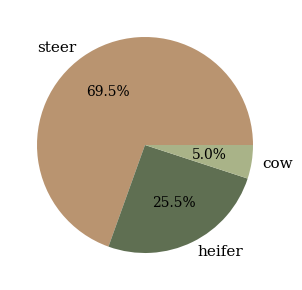

In [5]:
# pie chart: animal types
animal_types = beef['Animal Type'].value_counts()
plt.pie(animal_types.values, labels=animal_types.index, autopct='%1.1f%%',
    colors=[COLORS[-1], COLORS[0], COLORS[1]])
# plt.title('Trial 2: Animal Types')
plt.tight_layout()
plt.savefig("figs/beef_animal_types.svg", bbox_inches="tight")
plt.savefig("figs/beef_animal_types.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
print("Unique animals:", len(beef[beef['Animal Type'] != 'cow']))
print("Number of kill dates:", len(beef[beef['Animal Type'] != 'cow']['kill date'].unique()))
print("Earliest kill date:", beef[beef['Animal Type'] != 'cow']['kill date'].min())
print("Latest kill date:", beef[beef['Animal Type'] != 'cow']['kill date'].max())

Unique animals: 869
Number of kill dates: 48
Earliest kill date: 2020-04-02
Latest kill date: 2024-12-09


# Weather Patterns

In [6]:
weather_data = pd.read_csv("data/weather_preprocessed.csv")

C:\Users\kdo88\AppData\Local\Temp\ipykernel_22428\1960987225.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_data = pd.read_csv("data/weather_preprocessed.csv")


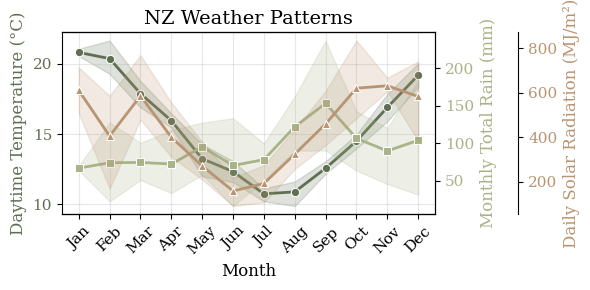

In [7]:
# Convert date to datetime and extract month and year
weather_data['Date'] = pd.to_datetime(weather_data['Date(NZST)'])
weather_data['Month'] = weather_data['Date'].dt.month
weather_data['Year'] = weather_data['Date'].dt.year

# Aggregate rain to daily totals then monthly totals (month-year)
daily_rain = weather_data.groupby('Date')['Rain(mm)'].sum().reset_index()
daily_rain['Year'] = pd.to_datetime(daily_rain['Date']).dt.year
daily_rain['Month'] = pd.to_datetime(daily_rain['Date']).dt.month
monthly_rain_data = daily_rain.groupby(['Year', 'Month'])['Rain(mm)'].sum().reset_index()

# Prepare daytime temperature data
weather_data['Hour'] = pd.to_datetime(weather_data['Time(NZST)'], format='%H:%M:%S', errors='coerce').dt.hour
weather_data['Temp_Type'] = weather_data['Hour'].apply(lambda h: 'Daytime' if 6 <= h < 18 else 'Nighttime')
daytime_temp = weather_data[weather_data['Temp_Type'] == 'Daytime'].copy()

# Aggregate to monthly means (month-year)
daytime_monthly_data = daytime_temp.groupby(['Year', 'Month'])['MnTemp(C)'].mean().reset_index()

# Aggregate solar radiation to daily totals then monthly totals (month-year)
daily_solar = weather_data.groupby('Date')['RadGlb(MJ/m2)'].sum().reset_index()
daily_solar['Year'] = pd.to_datetime(daily_solar['Date']).dt.year
daily_solar['Month'] = pd.to_datetime(daily_solar['Date']).dt.month
solar_monthly_data = daily_solar.groupby(['Year', 'Month'])['RadGlb(MJ/m2)'].sum().reset_index()

# Create figure with multiple y-axes
fig, ax1 = plt.subplots(figsize=(6, 3))

# Daytime temperature on left y-axis with 80% PI error bars
sns.lineplot(data=daytime_monthly_data, x='Month', y='MnTemp(C)', ax=ax1, color=COLORS[0], linewidth=2, marker='o', 
             errorbar=('pi', 80), label='Daytime Temperature (°C)', legend=False)
ax1.set_ylabel('Daytime Temperature (°C)', color=COLORS[0])
ax1.tick_params(axis='y', labelcolor=COLORS[0])

# Monthly rain on right y-axis with 80% PI error bars
ax2 = ax1.twinx()
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 0))
sns.lineplot(data=monthly_rain_data, x='Month', y='Rain(mm)', ax=ax2, color=COLORS[1], linewidth=2, marker='s', 
             errorbar=('pi', 80), label='Monthly Total Rain (mm)', legend=False)
ax2.set_ylabel('Monthly Total Rain (mm)', color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])

# Solar radiation on third y-axis with 80% PI error bars
ax3 = ax2.twinx()
ax3.spines['left'].set_visible(False)
ax3.spines['right'].set_position(('outward', 60))
sns.lineplot(data=solar_monthly_data, x='Month', y='RadGlb(MJ/m2)', ax=ax3, color=COLORS[2], linewidth=2, marker='^', 
             errorbar=('pi', 80), label='Daily Solar Radiation (MJ/m²)', legend=False)
ax3.set_ylabel('Daily Solar Radiation (MJ/m²)', color=COLORS[2])
ax3.tick_params(axis='y', labelcolor=COLORS[2])

# Ensure ax2 ticks are on the right (after ax3 creation)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')

ax1.set_xlabel('Month')
ax1.set_title('NZ Weather Patterns')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Convert date to datetime and extract month
weather_data['Date'] = pd.to_datetime(weather_data['Date(NZST)'])
weather_data['Month'] = weather_data['Date'].dt.month
weather_data['Hour'] = pd.to_datetime(weather_data['Time(NZST)'], format='%H:%M:%S', errors='coerce').dt.hour

In [9]:
# Data preparation
# Split temperature into daytime (6-18) and nighttime (18-6)
weather_data['Temp_Type'] = weather_data['Hour'].apply(lambda h: 'Daytime' if 6 <= h < 18 else 'Nighttime')

# Aggregate rain to daily totals
daily_rain = weather_data.groupby('Date')['Rain(mm)'].sum().reset_index()
daily_rain['Month'] = pd.to_datetime(daily_rain['Date']).dt.month

# Prepare long-format data for seaborn
plot_data = []
for var, col, data_source in [('Rain (mm/day)', 'Rain(mm)', daily_rain), 
                               ('Wind Speed (m/s)', 'MnSpd(mps)', weather_data)]:
    for month in range(1, 13):
        month_data = data_source[data_source['Month'] == month]
        if len(month_data) > 0:
            values = month_data[col].dropna()
            for val in values:
                plot_data.append({'Month': month, 'Variable': var, 'Value': val})

df_plot = pd.DataFrame(plot_data)

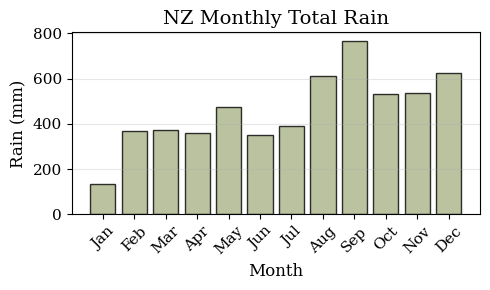

In [10]:
# Plot rain per month
monthly_rain = daily_rain.groupby('Month')['Rain(mm)'].sum().reset_index()
plt.figure(figsize=(5, 3))
plt.bar(monthly_rain['Month'], monthly_rain['Rain(mm)'], color=COLORS[1], alpha=0.8, edgecolor="black")
plt.ylabel('Rain (mm)')
plt.xlabel('Month')
plt.title('NZ Monthly Total Rain')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

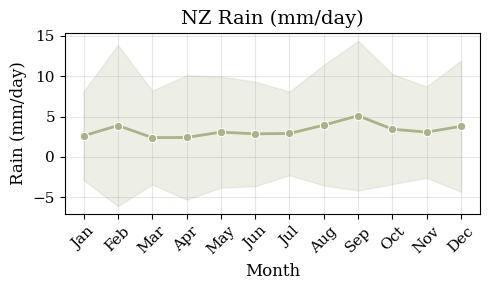

In [11]:
# Plot rain
plt.figure(figsize=(5, 3))
rain_data = df_plot[df_plot['Variable'] == 'Rain (mm/day)']
sns.lineplot(data=rain_data, x='Month', y='Value', color=COLORS[1], linewidth=2, marker='o', errorbar='sd')
plt.ylabel('Rain (mm/day)')
plt.xlabel('Month')
plt.title('NZ Rain (mm/day)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

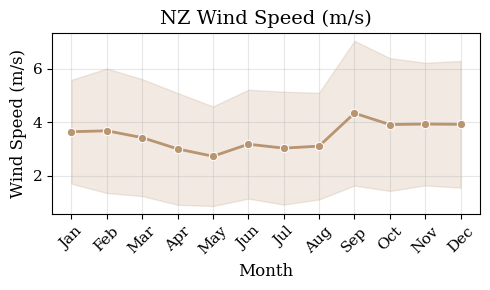

In [12]:
# Plot wind speed
plt.figure(figsize=(5, 3))
wind_data = df_plot[df_plot['Variable'] == 'Wind Speed (m/s)']
sns.lineplot(data=wind_data, x='Month', y='Value', color=COLORS[2], linewidth=2, marker='o', errorbar='sd')
plt.ylabel('Wind Speed (m/s)')
plt.xlabel('Month')
plt.title('NZ Wind Speed (m/s)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

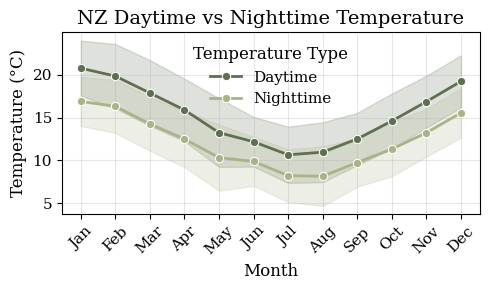

In [13]:
# Plot daytime vs nighttime temperature
plt.figure(figsize=(5, 3))
temp_plot_data = []
for temp_type in ['Daytime', 'Nighttime']:
    temp_data_filtered = weather_data[weather_data['Temp_Type'] == temp_type].copy()
    temp_data_filtered['Month'] = temp_data_filtered['Date'].dt.month
    
    for month in range(1, 13):
        month_temps = temp_data_filtered[temp_data_filtered['Month'] == month]['MnTemp(C)'].dropna()
        for val in month_temps:
            temp_plot_data.append({'Month': month, 'Temp_Type': temp_type, 'Value': val})

temp_df = pd.DataFrame(temp_plot_data)
if len(temp_df) > 0:
    palette = {'Daytime': COLORS[0], 'Nighttime': COLORS[1]}
    sns.lineplot(data=temp_df, x='Month', y='Value', hue='Temp_Type', palette=palette, linewidth=2, marker='o', errorbar='sd')
    plt.ylabel('Temperature (°C)')
    plt.xlabel('Month')
    plt.title('NZ Daytime vs Nighttime Temperature')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title='Temperature Type')
    plt.tight_layout()
    plt.show()

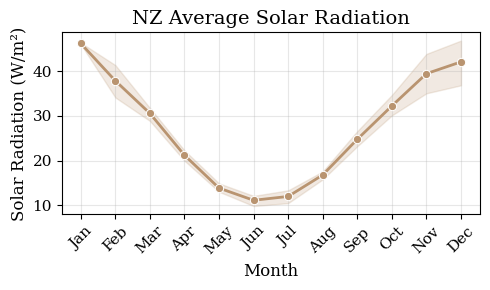

In [14]:
# Plot solar radiation (Average W/m2) per month
weather_data['Year'] = weather_data['Date'].dt.year
solar_monthly_data = weather_data.groupby(['Year', 'Month'])['Average W/m2'].mean().reset_index()

plt.figure(figsize=(5, 3))
sns.lineplot(data=solar_monthly_data, x='Month', y='Average W/m2', color=COLORS[2], linewidth=2, marker='o', errorbar=('pi', 80))
plt.ylabel('Solar Radiation (W/m²)')
plt.xlabel('Month')
plt.title('NZ Average Solar Radiation')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

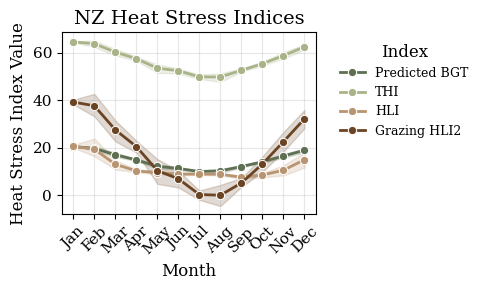

In [16]:
# Plot heat stress indices per month
heat_stress_cols = ['Predicted BGT', 'THI', 'HLI', 'Grazing HLI2']
heat_stress_data = []

for col in heat_stress_cols:
    monthly_data = weather_data.groupby(['Year', 'Month'])[col].mean().reset_index()
    monthly_data['Index'] = col
    monthly_data.rename(columns={col: 'Value'}, inplace=True)
    heat_stress_data.append(monthly_data)

heat_stress_df = pd.concat(heat_stress_data, ignore_index=True)

plt.figure(figsize=(5, 3))
palette = {'Predicted BGT': COLORS[0], 'THI': COLORS[1], 'HLI': COLORS[2], 'Grazing HLI2': '#6B4423'}
sns.lineplot(data=heat_stress_df, x='Month', y='Value', hue='Index', palette=palette, linewidth=2, marker='o', errorbar=('pi', 80))
plt.ylabel('Heat Stress Index Value')
plt.xlabel('Month')
plt.title('NZ Heat Stress Indices')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Index', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("figs/meat_heat_indices.svg", bbox_inches="tight")
plt.savefig("figs/meat_heat_indices.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
weather_data.columns

Index(['Station', 'Date(NZST)', 'Time(NZST)', 'MnDir(degT)', 'MnSpd(mps)',
       'MnTemp(C)', 'MnRH(%)', 'Rain(mm)', 'RadGlb(MJ/m2)', 'Average W/m2',
       'Predicted BGT', 'THI', 'HLI', 'Grazing HLI2', 'StdDir(degT)',
       'StdSpd(mps)', 'Date', 'Month', 'Year', 'Hour', 'Temp_Type'],
      dtype='object')

## Correlation of Windows with Targets

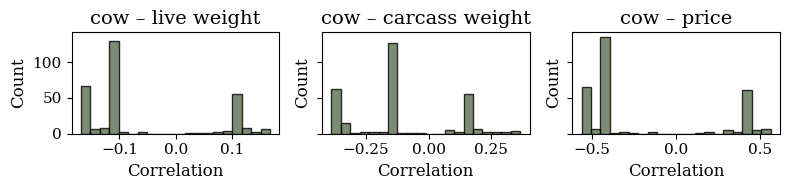

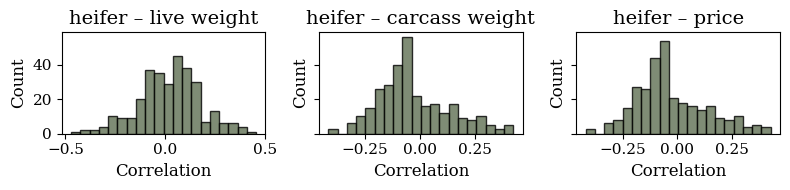

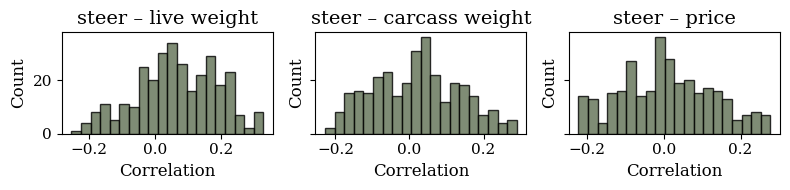

In [18]:
corrs = {}
targets = ["live weight", "carcass weight", "price"]

for atype, group in data.groupby("Animal Type"):
    sub = group[targets].join(df_windows)  # keep lag cols (even with NaNs)
    c = sub.corr(numeric_only=True)  # pairwise complete observations
    corrs[atype] = c.loc[df_windows.columns, targets].dropna(how="all")

for animal in beef['Animal Type'].dropna().unique():
    corr_df = corrs.get(animal)
    if corr_df is None:
        continue
    fig, axes = plt.subplots(1, len(targets), figsize=(8, 2), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, target in zip(axes, targets):
        vals = corr_df[target].dropna().values if target in corr_df.columns else np.array([])
        ax.hist(vals, bins=20, edgecolor="black", alpha=0.8, color=COLORS[0])
        ax.set_title(f"{animal} – {target}")
        ax.set_xlabel("Correlation")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Relevance of Number of Defects

In [19]:
cols_of_interest = ['kill month', 'NZDI', 'Animal Type', 'Transport distance (calculated)', 
                    'lairage time (calculated)', 'Total number of defects', 'Age']
targets = ["live weight", "carcass weight", "price/kg", "price"]

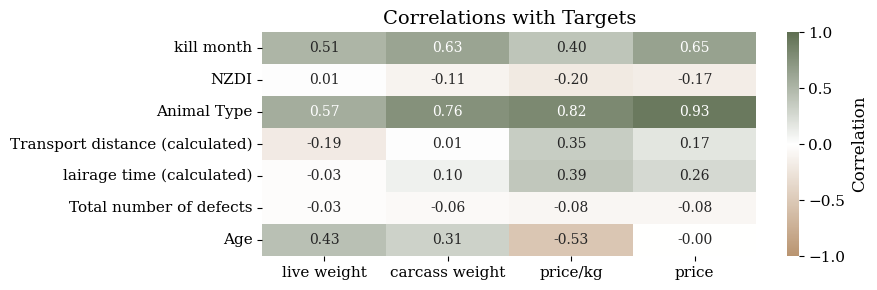

In [20]:
# make sure categorical col is numeric
df_corr = beef[cols_of_interest + targets].copy()
df_corr["Animal Type"] = df_corr["Animal Type"].astype("category").cat.codes

# compute correlation
corr = df_corr.corr(numeric_only=True).loc[cols_of_interest, targets]

# custom colormap
cmap = LinearSegmentedColormap.from_list("custom", [COLORS[2], "white", COLORS[0]])

# plot
plt.figure(figsize=(9,3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1,
            cbar_kws={"label": "Correlation"})
plt.title("Correlations with Targets")
plt.tight_layout()
plt.show()

## How many animals are we losing when including all of these features?

In [21]:
# How many animals are we losing when including these features?
features = ["Animal Type", "kill month", "Age", "Transport distance (calculated)", "lairage time (calculated)", "NZDI", "Total number of defects"]
targets = ["live weight", "carcass weight", "price"]
base = data[targets].dropna()
print("Initial dataset size:", len(base))
for i in range(len(features)):
    base = data[targets + features[:(i+1)]].dropna()
    print("After adding", features[i], ":", len(base))

Initial dataset size: 905
After adding Animal Type : 905
After adding kill month : 905
After adding Age : 905
After adding Transport distance (calculated) : 737
After adding lairage time (calculated) : 638
After adding NZDI : 638
After adding Total number of defects : 638


# Target Value Distributions

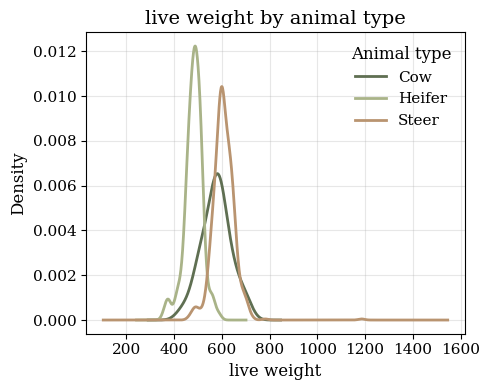

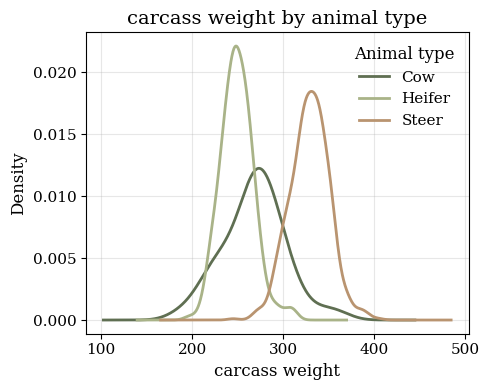

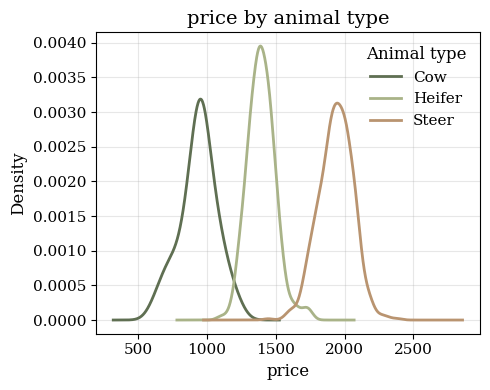

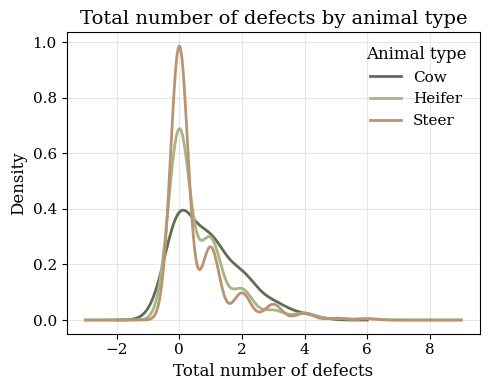

In [22]:
targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
animal_types = ['cow', 'heifer', 'steer']

# Normalise animal-type labels
beef['Animal Type'] = beef['Animal Type'].astype(str)

for target in targets:
    plt.figure(figsize=(5, 4))
    for color, atype in zip(COLORS, animal_types):
        mask = beef['Animal Type'].str.lower() == atype
        series = beef.loc[mask, target].dropna()
        if len(series) > 1:
            series.plot(
                kind='kde',
                label=atype.capitalize(),
                linewidth=2,
                color=color
            )

    plt.title(f"{target} by animal type")
    plt.xlabel(target)
    plt.ylabel("Density")
    plt.legend(title="Animal type")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Lairage Time vs. Life Weight

In [ ]:
import pandas as pd

for atype in ["cow", "steer", "heifer"]:
    sub = beef[beef["Animal Type"].str.lower() == atype].copy()
    sub = sub.dropna(subset=["lairage time (calculated)", "live weight"])

    if len(sub) < 3:
        print(f"{atype}: too few samples")
        continue

    pear = sub["lairage time (calculated)"].corr(sub["live weight"], method="pearson")
    spear = sub["lairage time (calculated)"].corr(sub["live weight"], method="spearman")

    print(f"\n=== {atype.upper()} ===")
    print(f"Pearson correlation:  {pear:.3f}")
    print(f"Spearman correlation: {spear:.3f}")



=== COW ===
Pearson correlation:  0.102
Spearman correlation: 0.087

=== STEER ===
Pearson correlation:  0.035
Spearman correlation: 0.005

=== HEIFER ===
Pearson correlation:  -0.365
Spearman correlation: -0.411


: 